In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import pandas
data = pandas.read_csv("churn.csv")

data = data.drop(columns = [ 'customerID' ])
data = data[data["TotalCharges"] != ' ']
data["TotalCharges"] = data["TotalCharges"].astype(float)

data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
cols_to_replace = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']  # названия нужных колонок
data[cols_to_replace] = data[cols_to_replace].replace(['No phone service', 'No internet service'], 'No')

In [4]:
import sklearn.model_selection

X = data.drop(columns = [ "Churn" ])
y = (data["Churn"] == "Yes").to_numpy()

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size = 0.1, stratify = y, random_state = 42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6328, 19), (704, 19), (6328,), (704,))

In [5]:
numeric = [ "tenure", "MonthlyCharges", "TotalCharges" ]
categorical = list(set(X_train.columns) - set(numeric))

len(numeric), len(categorical), len(X_train.columns)

(3, 16, 19)

In [6]:
import sklearn.compose
import sklearn.preprocessing

ct = sklearn.compose.ColumnTransformer(
    transformers=[
        ("numeric", 'passthrough', numeric),
        ("categorical", sklearn.preprocessing.OneHotEncoder(), categorical)
    ]
)
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

X_train.shape, X_test.shape

((6328, 39), (704, 39))

In [7]:
y_train.shape, y_test.shape

((6328,), (704,))

In [8]:
import sklearn.preprocessing

ss = sklearn.preprocessing.StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

In [9]:
pandas.DataFrame(X_test.copy(), columns = ct.get_feature_names_out())

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__Partner_No,categorical__Partner_Yes,categorical__Contract_Month-to-month,categorical__Contract_One year,categorical__Contract_Two year,categorical__SeniorCitizen_0,categorical__SeniorCitizen_1,...,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,categorical__OnlineBackup_No,categorical__OnlineBackup_Yes,categorical__OnlineSecurity_No,categorical__OnlineSecurity_Yes
0,1.0,20.45,20.45,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
1,34.0,19.70,675.60,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
2,48.0,29.50,1423.05,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,36.0,87.55,3078.10,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,64.0,81.25,5567.55,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,49.0,97.95,4917.90,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
700,72.0,84.20,5986.55,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
701,10.0,67.80,653.15,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
702,1.0,70.25,70.25,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [10]:
import numpy

X_train_df = pandas.DataFrame(X_train.copy(), columns = ct.get_feature_names_out())
X_test_df = pandas.DataFrame(X_test.copy(), columns = ct.get_feature_names_out())

for column in X_train_df.columns:
    if len(numpy.unique(X_train_df[column])) == 2:
        X_train_df[column] = X_train_df[column].astype(bool)
        X_test_df[column] = X_test_df[column].astype(bool)

X_train_df

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__Partner_No,categorical__Partner_Yes,categorical__Contract_Month-to-month,categorical__Contract_One year,categorical__Contract_Two year,categorical__SeniorCitizen_0,categorical__SeniorCitizen_1,...,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,categorical__OnlineBackup_No,categorical__OnlineBackup_Yes,categorical__OnlineSecurity_No,categorical__OnlineSecurity_Yes
0,3.0,55.80,154.55,False,True,True,False,False,True,False,...,False,False,False,False,False,True,True,False,True,False
1,10.0,19.80,198.25,True,False,False,True,False,True,False,...,False,True,False,False,False,True,True,False,True,False
2,49.0,106.65,5168.10,True,False,False,True,False,True,False,...,True,False,True,False,False,False,False,True,True,False
3,46.0,94.90,4422.95,True,False,False,True,False,True,False,...,True,False,False,True,False,False,False,True,True,False
4,10.0,19.95,187.75,False,True,True,False,False,True,False,...,False,True,True,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6323,36.0,92.90,3379.25,False,True,False,False,True,True,False,...,False,False,False,True,False,False,False,True,False,True
6324,10.0,65.90,660.05,False,True,False,True,False,True,False,...,False,False,False,False,False,True,False,True,True,False
6325,27.0,75.50,1893.95,False,True,True,False,False,False,True,...,True,False,False,False,True,False,True,False,True,False
6326,21.0,28.50,629.35,False,True,True,False,False,True,False,...,False,False,False,False,True,False,True,False,False,True


In [11]:
X_test_df

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__Partner_No,categorical__Partner_Yes,categorical__Contract_Month-to-month,categorical__Contract_One year,categorical__Contract_Two year,categorical__SeniorCitizen_0,categorical__SeniorCitizen_1,...,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,categorical__OnlineBackup_No,categorical__OnlineBackup_Yes,categorical__OnlineSecurity_No,categorical__OnlineSecurity_Yes
0,1.0,20.45,20.45,True,False,True,False,False,True,False,...,False,True,False,False,False,True,True,False,True,False
1,34.0,19.70,675.60,True,False,True,False,False,True,False,...,False,True,False,False,False,True,True,False,True,False
2,48.0,29.50,1423.05,False,True,True,False,False,True,False,...,False,False,False,True,False,False,True,False,True,False
3,36.0,87.55,3078.10,True,False,True,False,False,True,False,...,True,False,False,False,True,False,True,False,True,False
4,64.0,81.25,5567.55,True,False,False,True,False,True,False,...,False,False,False,False,True,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,49.0,97.95,4917.90,False,True,False,True,False,True,False,...,True,False,False,False,True,False,True,False,True,False
700,72.0,84.20,5986.55,False,True,False,False,True,True,False,...,False,False,True,False,False,False,True,False,False,True
701,10.0,67.80,653.15,False,True,True,False,False,True,False,...,False,False,False,True,False,False,True,False,True,False
702,1.0,70.25,70.25,True,False,True,False,False,True,False,...,True,False,False,False,True,False,True,False,True,False


In [12]:
import tqdm
import typing
import joblib

class LazyClassifierFCA:
    def __init__(
        self,

        min_pos_for_pos_clas: int = 0,
        pos_coef_for_pos_clas: float = 1,

        min_neg_for_neg_clas: int = 0,
        neg_coef_for_neg_clas: float = 1,

        pos_clas_coef: float = 1
    ):
        self.min_pos_for_pos_clas = min_pos_for_pos_clas
        self.pos_coef_for_pos_clas = pos_coef_for_pos_clas
        self.min_neg_for_neg_clas = min_neg_for_neg_clas
        self.neg_coef_for_neg_clas = neg_coef_for_neg_clas
        self.pos_clas_coef = pos_clas_coef

    def fit(self, X_train: pandas.DataFrame, y_train: pandas.Series):
        self.bool_columns = list(X_train.columns[X_train.dtypes == 'bool'])
        self.numeric_columns = list(X_train.columns[X_train.dtypes != 'bool'])

        self.binary_X_train_positive = X_train[y_train == 1][self.bool_columns].to_numpy().astype(bool)
        self.numerical_X_train_positive = X_train[y_train == 1][self.numeric_columns].to_numpy()
        self.binary_X_train_negative = X_train[y_train == 0][self.bool_columns].to_numpy().astype(bool)
        self.numerical_X_train_negative = X_train[y_train == 0][self.numeric_columns].to_numpy()


    def find_matches_impl(self, binary_intersection, numeric_intersection_minimums, numeric_intersection_maximums):
        binary_positive_match = (self.binary_X_train_positive | ~binary_intersection).all(axis = 1)
        binary_negative_match = (self.binary_X_train_negative | ~binary_intersection).all(axis = 1)
        
        numerical_positive_minimum = (numeric_intersection_minimums <= self.numerical_X_train_positive)
        numerical_positive_maximum = (self.numerical_X_train_positive <= numeric_intersection_maximums)
        numerical_positive_match = (numerical_positive_minimum & numerical_positive_maximum).all(axis = 1)

        numerical_negative_minimum = (numeric_intersection_minimums <= self.numerical_X_train_negative)
        numerical_negative_maximum = (self.numerical_X_train_negative <= numeric_intersection_maximums)
        numerical_negative_match = (numerical_negative_minimum & numerical_negative_maximum).all(axis = 1)

        num_positive = (binary_positive_match & numerical_positive_match).sum()
        num_negative = (binary_negative_match & numerical_negative_match).sum()
        return num_positive, num_negative

    def find_matches(self, sample_bin, sample_num, bin, num):
        binary_intersection = sample_bin & bin
        numeric_intersection_minimums = numpy.vstack([ sample_num, num ]).min(axis = 0)
        numeric_intersection_maximums = numpy.vstack([ sample_num, num ]).max(axis = 0)
        return self.find_matches_impl(binary_intersection, numeric_intersection_minimums, numeric_intersection_maximums)
    
    def classify_sample(self, sample: pandas.Series) -> typing.Any:
        sample_bin = sample[self.bool_columns].to_numpy().astype(bool)
        sample_num = sample[self.numeric_columns].to_numpy()

        positive_classifiers = 0
        for pos_bin, pos_num in zip(self.binary_X_train_positive, self.numerical_X_train_positive):
            num_positive, num_negative = self.find_matches(sample_bin, sample_num, pos_bin, pos_num)
            if self.pos_coef_for_pos_clas * num_positive > num_negative and num_positive >= self.min_pos_for_pos_clas:
                positive_classifiers += 1

        negative_classifiers = 0
        for neg_bin, neg_num in zip(self.binary_X_train_negative, self.numerical_X_train_negative):
            num_positive, num_negative = self.find_matches(sample_bin, sample_num, neg_bin, neg_num)
            if self.neg_coef_for_neg_clas * num_negative > num_positive and num_negative >= self.min_neg_for_neg_clas:
                negative_classifiers += 1

        positive_classifiers *= self.pos_clas_coef
        total = negative_classifiers + positive_classifiers
        return [ (negative_classifiers / total), (positive_classifiers / total) ]


    def predict(self, X_test: pandas.DataFrame) -> typing.List[typing.Any]:
        def do(sample):
            return self.classify_sample(sample)
        return joblib.Parallel(n_jobs = -1)(
            joblib.delayed(do)(sample)
            for _, sample in tqdm.tqdm(X_test.iterrows(), total = len(X_test))
        )

In [13]:
fca = LazyClassifierFCA(
    min_pos_for_pos_clas = 0,
    pos_coef_for_pos_clas = 5.0,

    min_neg_for_neg_clas = 0,
    neg_coef_for_neg_clas = 0.2,

    pos_clas_coef = 1.0
)
fca.fit(X_train_df, y_train)

### Predict

In [14]:
y_pred = fca.predict(X_test_df)

  0%|          | 0/704 [00:00<?, ?it/s]

KeyboardInterrupt: 

NameError: name 'y_pred' is not defined

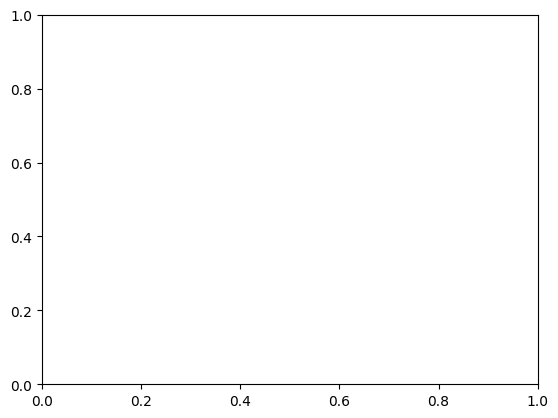

In [13]:
import matplotlib.pyplot as plt
from utils import estimate_quality

fig, axes = plt.subplots(1, 1)
estimate_quality(numpy.array(y_pred), y_test, ax = axes)

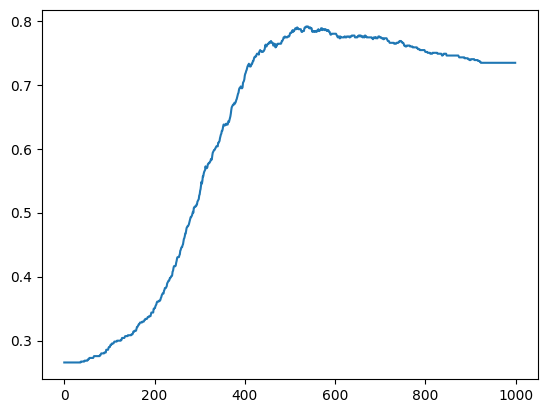

In [28]:
import sklearn.metrics

o = numpy.array(y_pred)
acc = []
for threshold in range(0, 1000):
    thr = threshold / 1000.
    bn = o[:, 1] > thr
    acc.append(sklearn.metrics.accuracy_score(bn, y_test))

plt.plot(list(range(0, 1000)), acc)

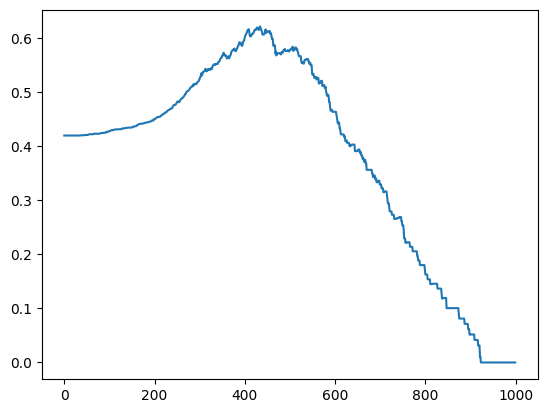

In [30]:
import sklearn.metrics

o = numpy.array(y_pred)
acc = []
for threshold in range(0, 1000):
    thr = threshold / 1000.
    u = o[:, 1] > thr
    acc.append(sklearn.metrics.f1_score(u, y_test))

plt.plot(list(range(0, 1000)), acc)

In [31]:
print('F1: ', numpy.max(acc))

F1:  0.6214442013129103


### Find params

In [14]:
def process_sample(sample):
    sample_bin = sample[fca.bool_columns].to_numpy().astype(bool)
    sample_num = sample[fca.numeric_columns].to_numpy()

    positive_classifiers_list = [
        fca.find_matches(sample_bin, sample_num, pos_bin, pos_num)
        for pos_bin, pos_num in zip(fca.binary_X_train_positive, fca.numerical_X_train_positive)
    ]
    negative_classifiers_list = [
        fca.find_matches(sample_bin, sample_num, neg_bin, neg_num)
        for neg_bin, neg_num in zip(fca.binary_X_train_negative, fca.numerical_X_train_negative)
    ]
    return positive_classifiers_list, negative_classifiers_list

classifier_lists = joblib.Parallel(n_jobs = -1)(
    joblib.delayed(process_sample)(sample)
    for _, sample in tqdm.tqdm(X_test_df.iterrows(), total = len(X_test_df))
)

  0%|          | 0/704 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [31]:
import pickle
with open('classifier_lists.pkl', 'wb') as f:
    pickle.dump(classifier_lists, f)

In [14]:
import itertools
import pickle
from utils import estimate_quality

min_pos_for_pos_clas_values = [0, 5, 10, 25, 50, 100, 250, 500]
pos_coef_for_pos_clas_values = [ 0.1, 0.25, 0.5, 0.75, 1.0, 2.5, 5.0, 7.5, 10.0 ]
min_neg_for_neg_clas_values = [0, 5, 10, 25, 50, 100, 250, 500, 1000, 1500 ]
neg_coef_for_neg_clas_values = [ 0.1, 0.25, 0.5, 0.75, 1.0, 2.5, 5.0, 7.5, 10.0 ]
pos_clas_coef_values = [ 0.5, 1.0, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0 ]
values = list(itertools.product(min_pos_for_pos_clas_values, pos_coef_for_pos_clas_values, min_neg_for_neg_clas_values, neg_coef_for_neg_clas_values, pos_clas_coef_values))

def process_params(min_pos_for_pos_clas, pos_coef_for_pos_clas, min_neg_for_neg_clas, neg_coef_for_neg_clas, pos_clas_coef):
    def is_positive_classifier(matches):
        num_positive, num_negative = matches
        return pos_coef_for_pos_clas * num_positive > num_negative and num_positive >= min_pos_for_pos_clas

    def is_negative_classifier(matches):
        num_positive, num_negative = matches
        return neg_coef_for_neg_clas * num_negative > num_positive and num_negative >= min_neg_for_neg_clas

    def make_pred(classifiers_lists):
        positive_classifiers_list, negative_classifiers_list = classifiers_lists
        positive_classifiers = sum(map(is_positive_classifier, positive_classifiers_list))
        negative_classifiers = sum(map(is_negative_classifier, negative_classifiers_list))

        positive_classifiers *= pos_clas_coef
        total = negative_classifiers + positive_classifiers
        if total == 0:
            return [0.5, 0.5]
        return [ (negative_classifiers / total), (positive_classifiers / total) ]

    with open('classifier_lists.pkl', 'rb') as f:
        classifier_lists = pickle.load(f)
    y_pred = list(map(make_pred, classifier_lists))
    metrics = estimate_quality(numpy.array(y_pred), y_test)
    return {
        'min_pos_for_pos_clas': min_pos_for_pos_clas,
        'pos_coef_for_pos_clas': pos_coef_for_pos_clas,
        'min_neg_for_neg_clas': min_neg_for_neg_clas,
        'neg_coef_for_neg_clas': neg_coef_for_neg_clas,
        'pos_clas_coef': pos_clas_coef,
        **metrics
    }

df_data = joblib.Parallel(n_jobs = -1)(
    joblib.delayed(process_params)(*params)
    for params in tqdm.tqdm(values)
)
df = pandas.DataFrame(df_data)
df.to_csv("selection_results.csv")
df

100%|██████████| 51840/51840 [10:57:04<00:00,  1.31it/s] 


,min_pos_for_pos_clas,pos_coef_for_pos_clas,min_neg_for_neg_clas,neg_coef_for_neg_clas,pos_clas_coef,Accuracy,Precision,Recall,AUC-ROC,F1-score,True Positive,True Negative,False Positive,False Negative,True Negative Rate (Specificity),Negative Predictive Value,False Positive Rate,False Discovery Rate
0,0,0.1,0,0.1,0.5,0.745739,0.785714,0.058824,0.789029,0.109453,11,514,3,176,0.994197,0.744928,0.005803,0.214286
1,0,0.1,0,0.1,1.0,0.758523,0.793103,0.122995,0.789029,0.212963,23,511,6,164,0.988395,0.757037,0.011605,0.206897
2,0,0.1,0,0.1,2.0,0.768466,0.671429,0.251337,0.789029,0.365759,47,494,23,140,0.955513,0.779180,0.044487,0.328571
3,0,0.1,0,0.1,2.5,0.772727,0.648352,0.315508,0.789029,0.424460,59,485,32,128,0.938104,0.791191,0.061896,0.351648
4,0,0.1,0,0.1,3.0,0.775568,0.630631,0.374332,0.789029,0.469799,70,476,41,117,0.920696,0.802698,0.079304,0.369369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51835,500,10.0,1500,10.0,2.5,0.654830,0.364078,0.401070,0.615480,0.381679,75,386,131,112,0.746615,0.775100,0.253385,0.635922
51836,500,10.0,1500,10.0,3.0,0.650568,0.358852,0.401070,0.611177,0.378788,75,383,134,112,0.740812,0.773737,0.259188,0.641148
51837,500,10.0,1500,10.0,3.5,0.649148,0.358491,0.406417,0.613256,0.380952,76,381,136,111,0.736944,0.774390,0.263056,0.641509
51838,500,10.0,1500,10.0,4.0,0.647727,0.356808,0.406417,0.611105,0.380000,76,380,137,111,0.735010,0.773931,0.264990,0.643192


In [19]:
df.sort_values(by = 'F1-score', ascending = False).head(20)

,min_pos_for_pos_clas,pos_coef_for_pos_clas,min_neg_for_neg_clas,neg_coef_for_neg_clas,pos_clas_coef,Accuracy,Precision,Recall,AUC-ROC,F1-score,True Positive,True Negative,False Positive,False Negative,True Negative Rate (Specificity),Negative Predictive Value,False Positive Rate,False Discovery Rate
21030,25,0.50,10,0.10,4.0,0.785511,0.581081,0.689840,0.816863,0.630807,129,424,93,58,0.820116,0.879668,0.179884,0.418919
10233,5,2.50,10,0.25,1.0,0.755682,0.527076,0.780749,0.824259,0.629310,146,386,131,41,0.746615,0.903981,0.253385,0.472924
14478,10,0.50,5,0.10,4.0,0.775568,0.560669,0.716578,0.817603,0.629108,134,412,105,53,0.796905,0.886022,0.203095,0.439331
14547,10,0.50,10,0.10,2.5,0.776989,0.563559,0.711230,0.817297,0.628842,133,414,103,54,0.800774,0.884615,0.199226,0.436441
21916,25,0.75,50,0.75,3.0,0.769886,0.550201,0.732620,0.812472,0.628440,137,405,112,50,0.783366,0.890110,0.216634,0.449799
21676,25,0.75,5,0.10,3.0,0.765625,0.542969,0.743316,0.826524,0.627540,139,400,117,48,0.773694,0.892857,0.226306,0.457031
21098,25,0.50,25,0.10,2.0,0.778409,0.567100,0.700535,0.816796,0.626794,131,417,100,56,0.806576,0.881607,0.193424,0.432900
7996,5,0.50,5,0.10,3.0,0.769886,0.550607,0.727273,0.815642,0.626728,136,406,111,51,0.785300,0.888403,0.214700,0.449393
27811,50,0.50,250,0.50,2.5,0.764205,0.541176,0.737968,0.794893,0.624434,138,400,117,49,0.773694,0.890869,0.226306,0.458824
22394,25,1.00,5,0.10,2.0,0.764205,0.541176,0.737968,0.823379,0.624434,138,400,117,49,0.773694,0.890869,0.226306,0.458824


In [22]:
import itertools
import pickle
from utils import estimate_quality

min_pos_for_pos_clas_values = [ 3, 4, 5, 6, 7 ]
pos_coef_for_pos_clas_values = [ 2.0, 2.25, 2.5, 2.75, 3.0 ]
min_neg_for_neg_clas_values = [ 7, 10, 13, 15, 17 ]
neg_coef_for_neg_clas_values = [ 0.15, 0.2, 0.25, 0.3, 0.35, 0.4 ]
pos_clas_coef_values = [ 0.5, 0.75, 1.0, 1.5, 2.0 ]
values = list(itertools.product(min_pos_for_pos_clas_values, pos_coef_for_pos_clas_values, min_neg_for_neg_clas_values, neg_coef_for_neg_clas_values, pos_clas_coef_values))

def process_params(min_pos_for_pos_clas, pos_coef_for_pos_clas, min_neg_for_neg_clas, neg_coef_for_neg_clas, pos_clas_coef):
    def is_positive_classifier(matches):
        num_positive, num_negative = matches
        return pos_coef_for_pos_clas * num_positive > num_negative and num_positive >= min_pos_for_pos_clas

    def is_negative_classifier(matches):
        num_positive, num_negative = matches
        return neg_coef_for_neg_clas * num_negative > num_positive and num_negative >= min_neg_for_neg_clas

    def make_pred(classifiers_lists):
        positive_classifiers_list, negative_classifiers_list = classifiers_lists
        positive_classifiers = sum(map(is_positive_classifier, positive_classifiers_list))
        negative_classifiers = sum(map(is_negative_classifier, negative_classifiers_list))

        positive_classifiers *= pos_clas_coef
        total = negative_classifiers + positive_classifiers
        if total == 0:
            return [0.5, 0.5]
        return [ (negative_classifiers / total), (positive_classifiers / total) ]

    with open('classifier_lists.pkl', 'rb') as f:
        classifier_lists = pickle.load(f)
    y_pred = list(map(make_pred, classifier_lists))
    metrics = estimate_quality(numpy.array(y_pred), y_test)
    return {
        'min_pos_for_pos_clas': min_pos_for_pos_clas,
        'pos_coef_for_pos_clas': pos_coef_for_pos_clas,
        'min_neg_for_neg_clas': min_neg_for_neg_clas,
        'neg_coef_for_neg_clas': neg_coef_for_neg_clas,
        'pos_clas_coef': pos_clas_coef,
        **metrics
    }

df2_data = joblib.Parallel(n_jobs = -1)(
    joblib.delayed(process_params)(*params)
    for params in tqdm.tqdm(values)
)
df2 = pandas.DataFrame(df2_data)
df2.to_csv("selection_results_2.csv")
df2

100%|██████████| 3750/3750 [50:17<00:00,  1.24it/s]


,min_pos_for_pos_clas,pos_coef_for_pos_clas,min_neg_for_neg_clas,neg_coef_for_neg_clas,pos_clas_coef,Accuracy,Precision,Recall,AUC-ROC,F1-score,True Positive,True Negative,False Positive,False Negative,True Negative Rate (Specificity),Negative Predictive Value,False Positive Rate,False Discovery Rate
0,3,2.0,7,0.15,0.50,0.774148,0.574468,0.577540,0.826762,0.576000,108,437,80,79,0.845261,0.846899,0.154739,0.425532
1,3,2.0,7,0.15,0.75,0.752841,0.523297,0.780749,0.826762,0.626609,146,384,133,41,0.742747,0.903529,0.257253,0.476703
2,3,2.0,7,0.15,1.00,0.703125,0.466867,0.828877,0.826762,0.597303,155,340,177,32,0.657640,0.913978,0.342360,0.533133
3,3,2.0,7,0.15,1.50,0.620739,0.404306,0.903743,0.826762,0.558678,169,268,249,18,0.518375,0.937063,0.481625,0.595694
4,3,2.0,7,0.15,2.00,0.571023,0.379455,0.967914,0.826762,0.545181,181,221,296,6,0.427466,0.973568,0.572534,0.620545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3745,7,3.0,17,0.40,0.50,0.761364,0.711111,0.171123,0.813646,0.275862,32,504,13,155,0.974855,0.764795,0.025145,0.288889
3746,7,3.0,17,0.40,0.75,0.772727,0.613445,0.390374,0.813646,0.477124,73,471,46,114,0.911025,0.805128,0.088975,0.386555
3747,7,3.0,17,0.40,1.00,0.757102,0.536036,0.636364,0.813646,0.581907,119,414,103,68,0.800774,0.858921,0.199226,0.463964
3748,7,3.0,17,0.40,1.50,0.683239,0.447674,0.823529,0.813646,0.580038,154,327,190,33,0.632495,0.908333,0.367505,0.552326


In [23]:
df2.sort_values(by = 'F1-score', ascending = False).head(20)

,min_pos_for_pos_clas,pos_coef_for_pos_clas,min_neg_for_neg_clas,neg_coef_for_neg_clas,pos_clas_coef,Accuracy,Precision,Recall,AUC-ROC,F1-score,True Positive,True Negative,False Positive,False Negative,True Negative Rate (Specificity),Negative Predictive Value,False Positive Rate,False Discovery Rate
1992,5,2.75,10,0.25,1.00,0.755682,0.526502,0.796791,0.824072,0.634043,149,383,134,38,0.740812,0.909739,0.259188,0.473498
2142,5,3.00,10,0.25,1.00,0.754261,0.524648,0.796791,0.824166,0.632696,149,382,135,38,0.738878,0.909524,0.261122,0.475352
3522,7,2.75,13,0.25,1.00,0.752841,0.522807,0.796791,0.822728,0.631356,149,381,136,38,0.736944,0.909308,0.263056,0.477193
2107,5,3.00,7,0.20,1.00,0.755682,0.526882,0.786096,0.825614,0.630901,147,385,132,40,0.744681,0.905882,0.255319,0.473118
757,4,2.00,7,0.20,1.00,0.757102,0.528986,0.780749,0.825645,0.630670,146,387,130,41,0.748549,0.904206,0.251451,0.471014
36,3,2.00,10,0.20,0.75,0.758523,0.531136,0.775401,0.825055,0.630435,145,389,128,42,0.752418,0.902552,0.247582,0.468864
3672,7,3.00,13,0.25,1.00,0.751420,0.520979,0.796791,0.822795,0.630021,149,380,137,38,0.735010,0.909091,0.264990,0.479021
1086,4,2.50,10,0.20,0.75,0.762784,0.537879,0.759358,0.825236,0.629712,142,395,122,45,0.764023,0.897727,0.235977,0.462121
1842,5,2.50,10,0.25,1.00,0.755682,0.527076,0.780749,0.824259,0.629310,146,386,131,41,0.746615,0.903981,0.253385,0.472924
3396,7,2.50,15,0.20,0.75,0.755682,0.527076,0.780749,0.822842,0.629310,146,386,131,41,0.746615,0.903981,0.253385,0.472924


In [24]:
fca = LazyClassifierFCA(
    min_pos_for_pos_clas = 5,
    pos_coef_for_pos_clas = 2.75,

    min_neg_for_neg_clas = 10,
    neg_coef_for_neg_clas = 0.25,

    pos_clas_coef = 1.0
)
fca.fit(X_train_df, y_train)
y_pred = fca.predict(X_test_df)

100%|██████████| 704/704 [06:30<00:00,  1.80it/s]


{'Accuracy': 0.7556818181818182,
 'Precision': 0.5265017667844523,
 'Recall': 0.7967914438502673,
 'AUC-ROC': 0.8240724459293125,
 'F1-score': 0.6340425531914894,
 'True Positive': 149,
 'True Negative': 383,
 'False Positive': 134,
 'False Negative': 38,
 'True Negative Rate (Specificity)': 0.7408123791102514,
 'Negative Predictive Value': 0.9097387173396675,
 'False Positive Rate': 0.25918762088974856,
 'False Discovery Rate': 0.4734982332155477}

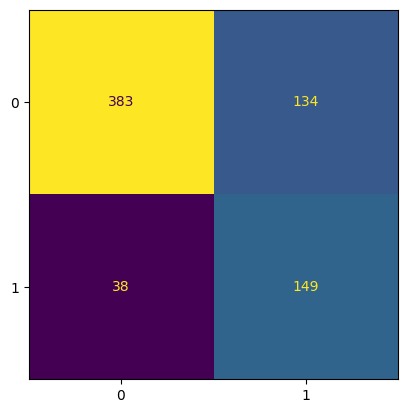

In [25]:
import matplotlib.pyplot as plt
from utils import estimate_quality

fig, axes = plt.subplots(1, 1)
estimate_quality(numpy.array(y_pred), y_test, ax = axes)

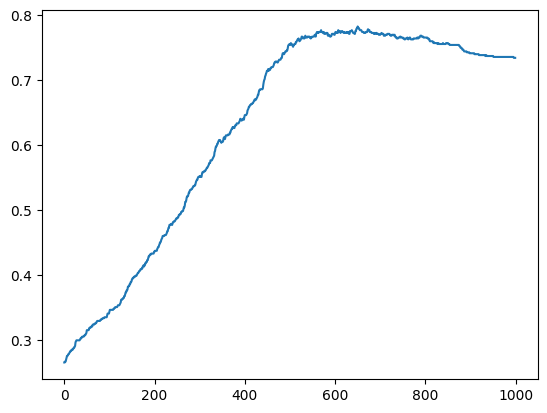

In [26]:
import sklearn.metrics

o = numpy.array(y_pred)
acc = []
for threshold in range(0, 1000):
    thr = threshold / 1000.
    bn = o[:, 1] > thr
    acc.append(sklearn.metrics.accuracy_score(bn, y_test))

plt.plot(list(range(0, 1000)), acc)

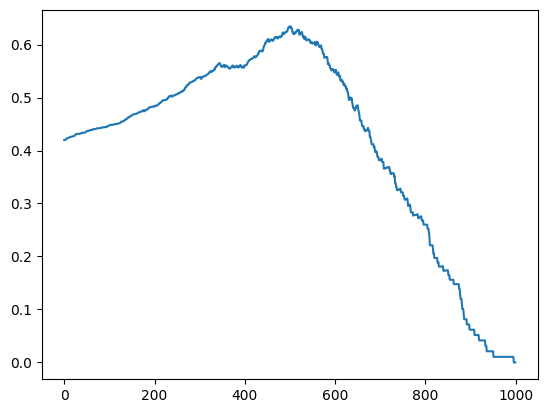

In [27]:
import sklearn.metrics

o = numpy.array(y_pred)
acc = []
for threshold in range(0, 1000):
    thr = threshold / 1000.
    u = o[:, 1] > thr
    acc.append(sklearn.metrics.f1_score(u, y_test))

plt.plot(list(range(0, 1000)), acc)

In [28]:
print('F1: ', numpy.max(acc))

F1:  0.6340425531914894
